## LangGraph Tools - Chatbot with Multiple Tools

In [2]:
## tools

import arxiv
import wikipedia
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

C:\Users\Nitish\AppData\Local\Temp\ipykernel_13784\921746096.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


In [3]:
# 1. Apply compatibility patch for arxiv >= 2.0.0
if not hasattr(arxiv.Search, "results"):
  arxiv.Search.results = lambda self: arxiv.Client().results(self)

In [4]:
# 2. Set user agent for wikipedia requests
wikipedia.set_user_agent("MyLangGraphApp/1.0 (contact@example.com)")

In [5]:
# 3. Create Arxiv tool
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv_tool = ArxivQueryRun(
    api_wrapper=api_wrapper_arxiv, description="Query arxiv papers"
)

In [6]:
# Test arxiv invocation
print(arxiv_tool.invoke("Attention is all you need."))

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi


In [7]:
# 4. FIX FOR WIKIPEDIA: Set a custom browser User-Agent to avoid HTTP 403 Forbidden
wikipedia.set_user_agent(
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like"
    " Gecko) Chrome/120.0.0.0 Safari/537.36"
)

In [8]:
# 5. Create wikipedia tool
api_wrapper_wiki = WikipediaAPIWrapper(
    top_k_results=2, doc_content_chars_max=500
)
wiki_tool = WikipediaQueryRun(
    api_wrapper=api_wrapper_wiki, description="Query wikipedia articles"
)
wiki_tool.name

'wikipedia'

In [9]:
# Test wikipedia tool
print(wiki_tool.invoke("India"))

Page: India
Summary: India, officially the Republic of India, is a country in South Asia.  It is the world's seventh-largest country by area and the largest by population. Bounded by the Indian Ocean on the south, the Arabian Sea on the southwest, and the Bay of Bengal on the southeast, it shares land borders with Pakistan to the west; China, Nepal, and Bhutan to the north; and Bangladesh and Myanmar to the east. In the Indian Ocean, India is near Sri Lanka and the Maldives.
Modern humans arrive


In [10]:
from dotenv import load_dotenv
import os
load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [11]:
# Tavily search tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily_tool = TavilySearchResults()

C:\Users\Nitish\AppData\Local\Temp\ipykernel_13784\893181019.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults()


In [12]:
# Test Tavily serach tool
tavily_tool.invoke("Today AI news")

[{'title': 'AI News Today 2026 | Latest AI Model Releases, Trends & ...',
  'url': 'https://www.buildfastwithai.com/blogs/collection/ai-industry-news-trends',
  'content': "### AI News Today July 23 2026: 16 Biggest Stories\n\nJuly 22, 2026Gemini 3.5 Flash Cyber: Google's AI Vulnerability Hunter\n\nAnalysis\n\n### Gemini 3.5 Flash Cyber: Google's AI Vulnerability Hunter\n\nJuly 22, 2026Gemini 3.6 Flash Review: Benchmarks, Price & API (2026)\n\nTutorials\n\n### Gemini 3.6 Flash Review: Benchmarks, Price & API (2026)\n\nJuly 22, 2026Qwen-Audio-3.0-TTS: Pricing, Languages & Benchmarks\n\nOptimization\n\n### Qwen-Audio-3.0-TTS: Pricing, Languages & Benchmarks\n\nJuly 22, 2026AI News Today July 22 2026: 16 Biggest Stories\n\nAI News\n\n### AI News Today July 22 2026: 16 Biggest Stories\n\nJuly 21, 2026Sakana Fugu-Cyber Review: Benchmarks & Access (2026)\n\nAnalysis\n\n### Sakana Fugu-Cyber Review: Benchmarks & Access (2026)\n\nJuly 21, 2026NVIDIA Cosmos 3 Edge: Complete Guide (2026)\n\nAnal

In [13]:
## Combine all these tools in the list
tools = [arxiv_tool, wiki_tool, tavily_tool]

In [14]:
## Intialize the LLM Model
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3.6-27b")

In [15]:
llm.invoke("What is AI?")

AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Understand User Query**: The user asks "What is AI?" - a broad, foundational question about Artificial Intelligence.\n\n2.  **Identify Key Components to Cover**:\n   - Definition of AI\n   - Core concepts (machine learning, deep learning, neural networks)\n   - Types of AI (narrow vs. general, weak vs. strong)\n   - How it works (briefly)\n   - Applications/Examples\n   - Current state & limitations\n   - Keep it clear, concise, and accessible\n\n3.  **Structure the Response**:\n   - Start with a simple, clear definition\n   - Explain key components/concepts\n   - Differentiate types of AI\n   - Give real-world examples\n   - Mention how it works (high-level)\n   - Note current capabilities & limitations\n   - Keep tone informative and neutral\n\n4.  **Draft - Section by Section**:\n   *(Definition)* AI, or Artificial Intelligence, refers to computer systems designed to perform tasks that typically require human intelli

In [16]:
# Bind LLM with tools
llm_with_tools = llm.bind_tools(tools=tools)

In [17]:
## Execute tool call through LLM
llm_with_tools.invoke("what is the recent new on ai?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'I need to find recent news about AI.\nI will use the `tavily_search_results_json` tool to search for "recent news on AI" or "latest AI news" to get up-to-date information.\nThen I will summarize the findings for the user.\n\nStep 1: Search for recent AI news.\nStep 2: Analyze the search results to identify key trends, new models, or major announcements.\nStep 3: Formulate a response summarizing the recent developments.\n\nI will start with the search.\n', 'tool_calls': [{'id': '8kf84mn6q', 'function': {'arguments': '{"query":"latest AI news today 2024"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 443, 'total_tokens': 594, 'completion_time': 0.287146371, 'completion_tokens_details': {'reasoning_tokens': 112}, 'prompt_time': 0.032596091, 'prompt_tokens_details': None, 'queue_time': 0.051236802, 'total_time': 0.319742462}, 'model_

## Create workflow

In [18]:
## Import required things
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage ## Human message or AI message
from typing import Annotated ## labelling
from langgraph.graph.message import add_messages ## Reducers in Langgraph


In [19]:
## State Schema
class State(TypedDict):
  messages: Annotated[list[AnyMessage], add_messages]

In [21]:
### Entire Chatbot with Langgraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

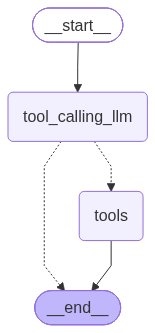

In [22]:
### Node defnition
def tool_calling_llm(state:State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Schedule the flow of the graph using edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
  "tool_calling_llm", 
  # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
  # If the latest messgae (result) from assistant is not a tool call -> tools_condition routes to llm
  tools_condition
)
builder.add_edge("tools", END)

# Compile it
graph = builder.compile()


# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
# Call the chatbot
messages = graph.invoke({"messages": "What is today's ai news?"})
for m in messages["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is today's ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (59z6j93fq)
 Call ID: 59z6j93fq
  Args:
    query: today's AI news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI Weekly: AI News — Today's Top Stories, Tracked & Ranked", "url": "https://aiweekly.co", "content": "cnbc.com · 7h ago\n\nGitHub Copilot adds side chats and worktree isolation for agents\n\ngithub.blog · 4h ago\n\nZvi's post-mortem: OpenAI still doesn't get the HuggingFace hack\n\nthezvi.substack.com · 3h ago\n\nSalem protesters bring a guillotine, chase off $5.1B AI data-center reps\n\ngizmodo.com · 6h ago\n\nSingapore PM vows to shield workers from AI disruption\n\nthestar.com.my · 4h ago\n\nWSJ: AI's 'Move 37' moment has arrived in mathematics\n\nwsj.com · 9h ago\n\

In [24]:
# Call the chatbot
messages = graph.invoke({"messages": "Hi, my name is Nitish"})
for m in messages["messages"]:
  m.pretty_print()

================================ Human Message =================================

Hi, my name is Nitish
================================== Ai Message ==================================

Hello Nitish! It's nice to meet you. How can I help you today?


## ReAct Architecture

In [ ]:
## ReAct Architecture

### Node defnition
def tool_calling_llm(state:State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Schedule the flow of the graph using edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
  "tool_calling_llm", 
  # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
  # If the latest messgae (result) from assistant is not a tool call -> tools_condition routes to llm
  tools_condition
)
builder.add_edge("tools", "tool_calling_llm")
# builder.add_edge("tool_calling_llm", END)

# Compile it
graph = builder.compile()


# View
# display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
# Call the chatbot
messages = graph.invoke({"messages": "Hey What is ai? and then please tell me the recent research papers on quantam computing?"})
for m in messages["messages"]:
  m.pretty_print()

================================ Human Message =================================

Hey What is ai? and then please tell me the recent research papers on quantam computing?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (09d9wk8wj)
 Call ID: 09d9wk8wj
  Args:
    query: Artificial Intelligence
================================= Tool Message =================================
Name: wikipedia

Page: Artificial intelligence
Summary: Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics, and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximise their cha
================================== Ai Message ====